<a href="https://colab.research.google.com/github/jak0110/Group-6-Project/blob/main/SpotifyTracks_Semeseter_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Acousticness vs Energy Visualization

#

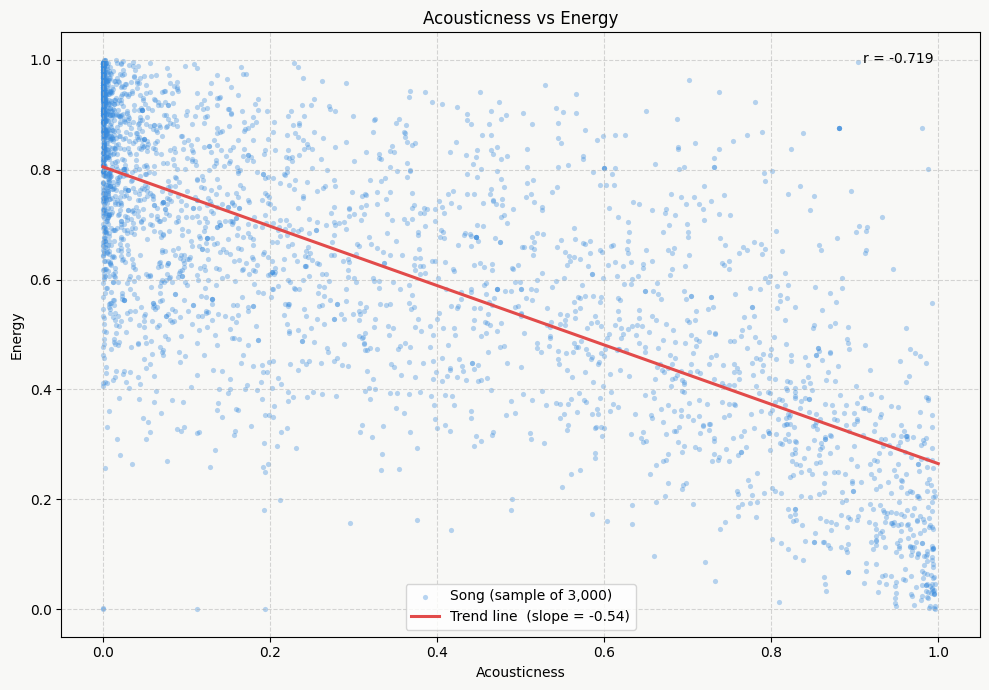

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Load Dataset
df = pd.read_csv("dataset.csv",
                 usecols=["acousticness", "energy"])
df = df.dropna()

# 3000 Sample to maintain readability
sample = df.sample(3000, random_state=43)

# Correlation
r = df["acousticness"].corr(df["energy"])

m, b = np.polyfit(sample["acousticness"], sample["energy"], 1)
x_line = np.linspace(0, 1, 200)
y_line = m * x_line + b

# Build plot
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#F8F8F6")
ax.set_facecolor("#F8F8F6")

# Scatter Plot
ax.scatter(
    sample["acousticness"], sample["energy"],
    color="#378ADD", alpha=0.35, s=14, linewidths=0,
    label="Song (sample of 3,000)"
)

# Trend line
ax.plot(x_line, y_line, color="#E24B4A", linewidth=2.2,
        label=f"Trend line  (slope = {m:.2f})")

# Annotation
ax.text(0.95, 0.95, f"r = {r:.3f}", transform=ax.transAxes, ha="right")

#Labels
ax.set_xlabel("Acousticness")
ax.set_ylabel("Energy")
ax.set_title("Acousticness vs Energy")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# 3. Simple Layout
plt.tight_layout()

# Hierarchical Cluster Dendrogram

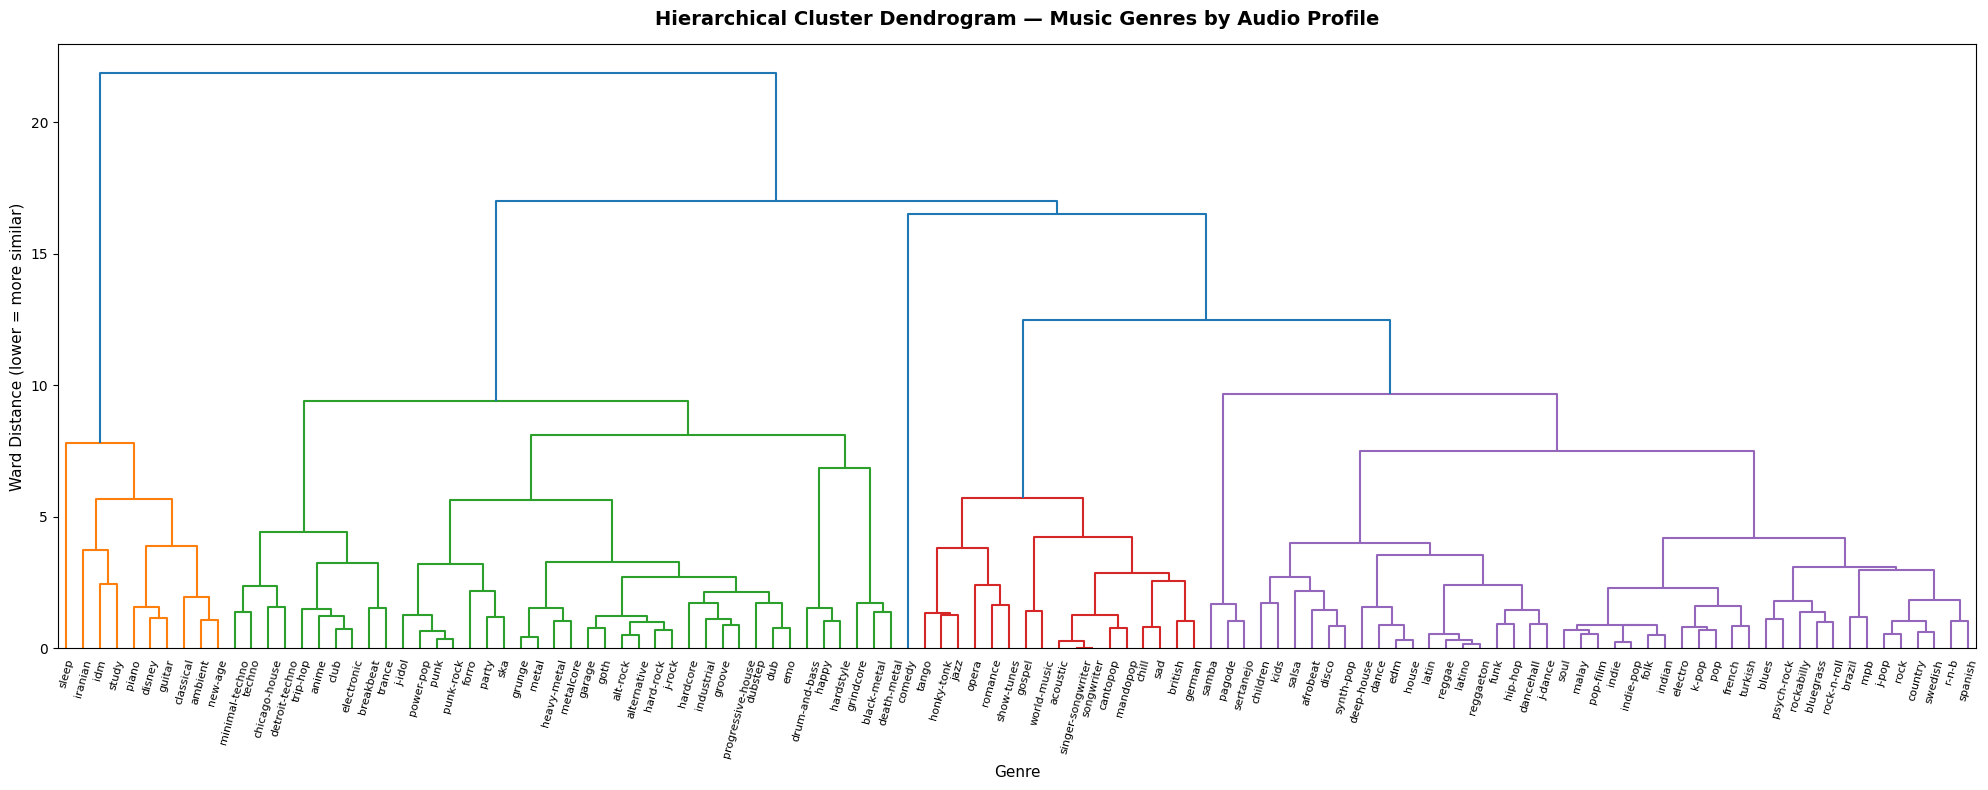

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset.csv')

features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

genre_profiles = df.groupby('track_genre')[features].mean()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(genre_profiles)

Z = linkage(X_scaled, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(20, 8))

dendrogram(
    Z,
    labels=genre_profiles.index.tolist(),  # genre names as leaf labels
    ax=ax,
    leaf_rotation=75,                       # angle genre names on x-axis
    leaf_font_size=8,                       # font size for genre labels
    color_threshold=0.55 * max(Z[:, 2])    # auto-color clusters above this distance
)

ax.set_title('Hierarchical Cluster Dendrogram — Music Genres by Audio Profile',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Ward Distance (lower = more similar)', fontsize=11)

plt.tight_layout()
plt.savefig('hierarchical_cluster.png', dpi=150, bbox_inches='tight')
plt.show()